In [1]:
from typing import List, Tuple, Dict, Optional, Sequence, Any
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader    
import math
import json
from itertools import permutations, combinations

import numpy as np
from tqdm.auto import tqdm


import pennylane as qml 

import cProfile
import pstats

In [2]:
import os, sys
sys.path.append('../../')

from pqcqec.utils.constants import QUBITS_FOR_GATES, QISKIT_GATES, GATE_IS_DIRECTIONAL
from pqcqec.noise.simple_noise import PennylaneNoisyGates
# from pqcqec.simulate.simulate import run_circuit_with_noise_model
from pqcqec.circuits.modify import pennylane_state_embedding

# Tokenizer / Encoder for Data

In [3]:
class SimpleCircuitTokenizer:
    """
    Tokenizes quantum circuit operations into unique integer IDs.

    This class creates a vocabulary of all possible 1-qubit and 2-qubit
    operations for a given gateset and number of qubits. It can then
    encode a circuit (a sequence of operations) into a list of token IDs
    and decode them back.

    Gate names are treated case-insensitively. A padding token ID can be
    specified.
    """

    def __init__(
        self,
        gateset: Sequence[str],
        num_qubits: int,
        qubits_for_gates: dict[str, int],
        undirected_gates: Sequence[str] | None = None,
    ):
        """
        Initializes the tokenizer and builds the operation vocabulary.

        Args:
            gateset: A sequence of supported gate names (e.g., ['h', 'cx']).
            num_qubits: The number of qubits in the device.
            undirected_gates: A sequence of 2-qubit gates that are
                symmetrical (e.g., 'cz'). For these, (gate, (q1, q2)) is
                the same as (gate, (q2, q1)).
            pad_id: The integer ID to reserve for padding.
        """
        if num_qubits < 1:
            raise ValueError("Number of qubits must be at least 1.")
        self.num_qubits = num_qubits

        # Normalize gate names to lowercase for case-insensitive handling
        self.gates = {g.lower() for g in gateset}
        self.undirected = {g.lower() for g in (undirected_gates or [])}
        self.qubits_for_gates = {g.lower(): qubits_for_gates[g] for g in qubits_for_gates}

        # Validate that undirected gates are part of the main gateset
        if not self.undirected.issubset(self.gates):
            unknown = self.undirected - self.gates
            raise ValueError(f"Undirected gates {unknown} are not in the main gateset.")

        # --- Build Vocabulary ---
        # The vocabulary maps (gate_name, (qubits,)) tuples to integer IDs.
        # This is built once at initialization for efficiency.

        self.pad_id = 0
        # self.unk_id = 1

        self.pad_gate = "pad"
        # self.unk_gate = "unk"

        self.pad_token = (self.pad_gate, ())
        # self.unk_token = (self.unk_gate, ())

        self.op_to_id: dict[tuple[str, tuple[int, ...]], int] = {self.pad_token: self.pad_id}
        self.id_to_op: dict[int, tuple[str, tuple[int, ...]]] = {self.pad_id: self.pad_token}

        self._build_vocab()

    @property
    def vocab_size(self) -> int:
        """Returns the total number of unique tokens, including padding."""
        return len(self.op_to_id)

    def _build_vocab(self) -> None:
        """
        Generates all 1- and 2-qubit operations using combinations/permutations
        and assigns deterministic IDs (no if-branches inside).
        """
        sorted_gates = sorted(self.gates)
        next_id = len(self.id_to_op)  # 0 is PAD
        qubits = range(self.num_qubits)
        # print(singles, directed_pairs, undirected_pairs)

        for g in sorted_gates:
            q_count = self.qubits_for_gates.get(g, None)
            qubit_tokens = list(combinations(qubits, q_count)) if g in self.undirected else list(permutations(qubits, q_count))
            for qs in qubit_tokens:
                op = (g, tuple(qs))
                self.op_to_id[op] = next_id
                self.id_to_op[next_id] = op
                next_id += 1

    def _canonicalize_op(self, gate: str, qubits: Sequence[int]) -> tuple[str, tuple[int, ...]]:
        """
        Normalizes an operation and validates its components.
        - Lowercases the gate name.
        - Sorts qubit indices for undirected gates.
        - Validates gate name, qubit count, and qubit indices.
        """
        g = gate.lower()
        if g not in self.gates:
            raise ValueError(f"Gate '{gate}' is not in the tokenizer's gateset.")

        qs = tuple(qubits)
        if not (1 <= len(qs) <= 2):
            raise ValueError(f"Only 1- and 2-qubit operations are supported, but got {len(qs)} qubits for gate '{gate}'.")
        
        for q in qs:
            if not (0 <= q < self.num_qubits):
                raise ValueError(f"Qubit index {q} is out of range for a device with {self.num_qubits} qubits.")

        if len(qs) == 2:
            if qs[0] == qs[1]:
                raise ValueError("A 2-qubit operation must act on two different qubits.")
            # For undirected gates, sort qubits to get the canonical form (e.g., (1, 2) not (2, 1))
            if g in self.undirected:
                qs = tuple(sorted(qs))
        
        return g, qs


    def encode(self, circuit: Sequence[tuple[str, Sequence[int], Any]]) -> list[int]:
        """
        Encodes a sequence of circuit operations into token IDs.

        Args:
            circuit: A list of operations, where each operation is a tuple
                     like ('gate_name', [qubit_indices], params). The params
                     are ignored.

        Returns:
            A list of integer token IDs corresponding to the operations.
        """
        token_ids = []
        for gate, qubits, *_ in circuit:
            op = self._canonicalize_op(gate, qubits)
            token_ids.append(self.op_to_id[op])
        return token_ids

    def decode(self, token_ids: Sequence[int]) -> list[list[Any]]:
        """
        Decodes a sequence of token IDs back into circuit operations.

        Args:
            token_ids: A list of integer token IDs.

        Returns:
            A list of operations in the format [['gate_name', [qubits], []]].
            Padding tokens are ignored.
        """
        circuit = []
        for token_id in token_ids:
            if token_id == self.pad_id:
                continue
            
            if token_id not in self.id_to_op:
                raise KeyError(f"Token ID {token_id} is not in the vocabulary.")
            
            gate, qubits = self.id_to_op[token_id]
            circuit.append([gate, list(qubits), []])
        return circuit

    def print_vocab(self, limit: int | None = 20) -> None:
        """Print up to `limit` vocab entries by token id (ascending).
        Pass None to print all.
        """
        for token_id in sorted(self.id_to_op.keys())[:limit]:
            gate, qubits = self.id_to_op[token_id]
            print(f"ID {token_id:3}: Gate '{gate}' on qubits {qubits}")

    def __repr__(self) -> str:
        return (
            f"CircuitTokenizer(vocab_size={self.vocab_size}, num_qubits={self.num_qubits}, "
            f"pad_id={self.pad_id}, num_gates={len(self.gates)})"
        )


In [4]:
class SimpleCircuitDataset(Dataset):
    def __init__(self, tokenizer: SimpleCircuitTokenizer, circuit_data: List):
        """
        Args:
            tokenizer: An instance of SimpleCircuitTokenizer to encode circuit operations.
            circuit_data: A list of circuits, pqc params, and the measured fidelity where each circuit is a list of operations.
                         Each operation is a tuple (gate_name, qubit_indices, params).
                         Each PQC param is of a fixed shape. 
                         Each Fidelity is a single float value <= 1.0. 
        """
        self.tokenizer = tokenizer
        self.circuit_data = circuit_data

    def __len__(self) -> int:
        return len(self.circuit_data)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Returns:
            A tuple containing:
            - Encoded tokens as a tensor of shape [L], where L is the sequence length.
            - Attention mask as a tensor of shape [L], where 1 indicates valid tokens and 0 indicates padding.
        """
        circuit = self.circuit_data[idx]
        # print(circuit)
        input_ids = self.tokenizer.encode(circuit)  # Encode the circuit into token IDs
        attention_mask = [1 for x in input_ids if x != self.tokenizer.pad_id]  # Create an attention mask with 1s for valid tokens

        # Convert to tensors
        transformer_dict = {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "attention_mask": torch.tensor(attention_mask, dtype=torch.long)
        }
        # params_tensor = torch.tensor(params, dtype=torch.float)
        # fidelity_tensor = torch.tensor(fidelity, dtype=torch.float)

        return transformer_dict

# Transformer

In [5]:
# ---------------- Positional encoding (batch_first) ----------------
class PositionalEncodingBF(nn.Module):
    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 512):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)                                  # [L, C]
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1) # [L, 1]
        div_term = torch.exp(torch.arange(0, d_model, 2).float()
                             * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # [1, L, C] for batch_first broadcasting
        self.register_buffer("pe", pe, persistent=False)

    def forward(self, x):  # x: [B, L, C]
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


# ---------------- Simple Transformer Encoder -> angle regressor ----------------
class SimpleTransformer(nn.Module):
    def __init__(self,
                 vocab_size: int,
                 out_shape: tuple,   # (K, Q, P)
                 d_model: int = 128,
                 nhead: int = 2,
                 num_encoder_layers: int = 2,
                 dim_feedforward: int = 256,
                 dropout: float = 0.1,
                 pad_id: int = 0,
                 max_len: int = 128):
        super().__init__()
        self.K, self.Q, self.P = out_shape
        self.out_dim = self.K * self.Q * self.P
        self.d_model = d_model
        self.pad_id = pad_id

        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.pos_encoder = PositionalEncodingBF(d_model, dropout, max_len=max_len)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_encoder_layers)

        self.regression_head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Linear(d_model // 2, self.out_dim)
        )

    def forward(self, input_ids, attention_mask=None):  # [B, L] or [L]
        # Check if input is batched or singular
        is_batched = input_ids.dim() == 2

        if not is_batched:
            input_ids = input_ids.unsqueeze(0)  # Add batch dimension for singular data
            if attention_mask is not None:
                attention_mask = attention_mask.unsqueeze(0)

        # Embedding + scale
        x = self.embedding(input_ids) * math.sqrt(self.d_model)  # [B, L, C]
        x = self.pos_encoder(x)

        # Key padding mask: True where padding should be ignored
        if attention_mask is None:
            key_padding_mask = (input_ids == self.pad_id)  # [B, L]
        else:
            key_padding_mask = ~attention_mask.bool()  # Invert mask to match padding logic

        # Encoder
        x = self.encoder(x, src_key_padding_mask=key_padding_mask)  # [B, L, C]

        # Masked mean pool over tokens
        mask = (~key_padding_mask).unsqueeze(-1).float()  # [B, L, 1]
        denom = mask.sum(dim=1).clamp_min(1.0)            # [B, 1]
        pooled = (x * mask).sum(dim=1) / denom            # [B, C]

        # Regress angles
        y = self.regression_head(pooled)                  # [B, K*Q*P]
        y = y.view(-1, self.K, self.Q, self.P)            # [B, K, Q, P]

        if not is_batched:
            y = y.squeeze(0)  # Remove batch dimension for singular data

        return y


# Loss Functions

In [6]:
def cosine_loss(pred_angles: torch.Tensor, target_angles: torch.Tensor) -> torch.Tensor:
    """
    Computes cosine loss between predicted and target angles.
    """
    
    cos_loss = 1 - torch.cos(pred_angles - target_angles)
    return cos_loss.mean()


def torch_pure_state_fidelity(psi: torch.Tensor, phi: torch.Tensor) -> torch.Tensor:
    """
    Computes batch fidelity F = |⟨ψ|φ⟩|² between two state-vector tensors.

    Args:
        psi: Complex tensor of shape (batch_size, 2**n)
        phi: Complex tensor of shape (batch_size, 2**n)

    Returns:
        Scalar fidelity tensor of shape (batch_size,) with values in [0, 1]
    """
    # Ensure the tensors are complex floats
    psi = psi.to(torch.complex64)
    phi = phi.to(torch.complex64)

    # Normalize each state vector in the batch along the last dimension
    psi_norm = torch.linalg.norm(psi, dim=-1, keepdim=True) + 1e-12
    phi_norm = torch.linalg.norm(phi, dim=-1, keepdim=True) + 1e-12
    psi_normalized = psi / psi_norm
    phi_normalized = phi / phi_norm

    # Compute the batch dot product.
    # The conjugate of psi_normalized is taken element-wise.
    # The sum is over the last dimension to compute the dot product for each
    # state in the batch.
    overlap = torch.sum(psi_normalized.conj() * phi_normalized, dim=-1)
    
    fidelity = torch.abs(overlap) ** 2

    # Clip to [0, 1] to handle potential numerical floating point errors
    return torch.clamp(fidelity.real, 0.0, 1.0)


def torch_fidelity_loss(ideal: torch.Tensor, measured: torch.Tensor) -> torch.Tensor:
    """
    Calculates the fidelity-based loss for a batch of states.
    Loss = 1 - F(ideal, measured)

    Args:
        ideal: Ideal state vectors, shape (batch_size, 2**n)
        measured: Measured state vectors, shape (batch_size, 2**n)

    Returns:
        The mean loss over the batch as a single scalar tensor.
    """
    fidelities = torch_pure_state_fidelity(ideal, measured)
    
    # Calculate loss for each item in the batch and then take the mean
    loss = 1.0 - fidelities
    return torch.mean(loss)




# Train

In [7]:
# # ----------------------------
# # Train / Validate Helpers
# # ----------------------------

# def interleave_tensor_pqc_in_circuit(base_ops:list, qubits:int, blocks:int, pqc_gates:list, params:np.ndarray):
#     """Interleave PQC operations into the base circuit."""
#     interleaved_circuit = []
#     # print(params.shape)
#     for i, op in enumerate(base_ops):
#         # print(i, op)
#         interleaved_circuit.append(op)
#         if (i + 1) % blocks == 0:
#             k = (i + 1) // blocks - 1
#             # print(f"Interleaving PQC operations for block {k}")
#             for q in range(qubits):
#                 for j, g in enumerate(pqc_gates):
#                     # print(g, q, (k,q,j), params[k, q, j])
#                     interleaved_circuit.append((g, [q], params[k, q, j]))
#     return interleaved_circuit    

# @torch.no_grad()
# def evaluate_epoch(model: nn.Module, dataloader, loss_fn, device: torch.device,
#                    noise_dist: dict, tokenizer:SimpleCircuitTokenizer) -> float:
#     model.eval()
#     total_loss = 0.0
#     total_batches = 0
#     no_noise_model = PennylaneNoisyGates(0,0,0,0)
#     noise_model = PennylaneNoisyGates(**noise_dist)
#     for batch in dataloader:
#         x: Dict[str, Any]
#         y, _ = None, None
#         x = batch  # transformer_dict, params_tensor, fidelity_tensor
#         input_ids = x['input_ids'].to(device)
#         attention_mask = x.get('attention_mask', None)
#         if attention_mask is not None:
#             attention_mask = attention_mask.to(device)

#         pred = model(input_ids, attention_mask=attention_mask)

#         # Fix: Convert to CPU and numpy before decoding
#         circuit_ops_list = [tokenizer.decode(ids.cpu().numpy()) for ids in input_ids]

#         # Simple now, will be batched with complex states later
#         input_state = torch.zeros((input_ids.shape[0], 2**tokenizer.num_qubits), dtype=torch.complex64, device=device)
#         input_state[:, 0] = 1.0 + 0.0j  # |00...0> state

#         ideal_outputs = [run_circuit_with_noise_model_torch(ops, input_state[i], no_noise_model, tokenizer.num_qubits, device)
#                          for i, ops in enumerate(circuit_ops_list)]
        
#         pred_thetas = pred.cpu().numpy()
#         blocks = pred_thetas.shape[1]

#         noisy_outputs = [
#             run_circuit_with_noise_model_torch(
#                 interleave_tensor_pqc_in_circuit(ops, tokenizer.num_qubits, blocks, ['rz', 'rx', 'rz'], pred_thetas[i]),
#                 input_state[i], noise_model, tokenizer.num_qubits, device
#                 ) for i, ops in enumerate(circuit_ops_list)]

#         ideal_outputs_torch = torch.stack(ideal_outputs)
#         noisy_outputs_torch = torch.stack(noisy_outputs)

#         loss = torch_fidelity_loss(ideal_outputs_torch, noisy_outputs_torch)
        
#         # loss = fidelity_loss(torch.stack(ideal_outputs), torch.stack(noisy_outputs))

#         total_loss += float(loss.detach().cpu())
#         total_batches += 1
#     return total_loss / max(1, total_batches)



# def train_epoch(model: nn.Module, dataloader, 
#                 optimizer: torch.optim.Optimizer, 
#                 loss_fn, device: torch.device,
#                 noise_dist: dict, tokenizer:SimpleCircuitTokenizer,
#                 grad_clip: Optional[float] = None) -> float:
    
#     model.train()
#     total_loss = 0.0
#     total_batches = 0
#     no_noise_model = PennylaneNoisyGates(0,0,0,0)
#     noise_model = PennylaneNoisyGates(**noise_dist)

#     for batch in tqdm(dataloader):
#         x = batch  # transformer_dict, params_tensor, fidelity_tensor
        
#         input_ids = x['input_ids'].to(device)
#         attention_mask = x.get('attention_mask', None)
#         if attention_mask is not None:
#             attention_mask = attention_mask.to(device)
        
#         optimizer.zero_grad(set_to_none=True)
#         pred = model(input_ids, attention_mask=attention_mask)
        
#         # Fix: Convert to CPU and numpy before decoding
#         circuit_ops_list = [tokenizer.decode(ids.cpu().numpy()) for ids in input_ids]

#         input_state = torch.zeros((input_ids.shape[0], 2**tokenizer.num_qubits), dtype=torch.complex64, device=device)
#         input_state[:, 0] = 1.0 + 0.0j  # |00...0> state

#         ideal_outputs = [run_circuit_with_noise_model(ops, input_state[i], no_noise_model, tokenizer.num_qubits, device)
#                          for i, ops in enumerate(circuit_ops_list)]
        
#         pred_thetas = pred.cpu().numpy()
#         blocks = pred_thetas.shape[1]

#         noisy_outputs = [
#             run_circuit_with_noise_model(
#                 interleave_tensor_pqc_in_circuit(ops, tokenizer.num_qubits, blocks, ['rz', 'rx', 'rz'], pred_thetas[i]),
#                 input_state[i], noise_model, tokenizer.num_qubits, device
#                 ) for i, ops in enumerate(circuit_ops_list)]

#         ideal_outputs_torch = torch.stack(ideal_outputs)
#         noisy_outputs_torch = torch.stack(noisy_outputs)

#         # print(ideal_outputs_torch.shape, noisy_outputs_torch.shape)

#         # print(ideal_outputs)

#         # print(noisy_outputs)

#         loss = torch_fidelity_loss(ideal_outputs_torch, noisy_outputs_torch)

        
#         loss.backward()
#         if grad_clip is not None:
#             torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
#         optimizer.step()

#         total_loss += float(loss.detach().cpu())
#         total_batches += 1
#     return total_loss / max(1, total_batches)


# def train(model: nn.Module,
#         train_loader,
#         val_loader,
#         optimizer: torch.optim.Optimizer,
#         loss_fn,
#         device: torch.device,
#         noise_dist: dict,
#         tokenizer:SimpleCircuitTokenizer,
#         epochs: int = 10,
#         grad_clip: Optional[float] = None) -> Tuple[List[float], List[float]]:
    
#     """Train and validate the model, returning history.
#     Returns: (train_losses: List[float], val_losses: List[float])
#     """
#     train_hist, val_hist = [], []
#     for epoch in range(1, epochs + 1):
#         tr_loss = train_epoch(model, train_loader, optimizer, loss_fn, device, noise_dist, tokenizer, grad_clip)
#         va_loss = evaluate_epoch(model, val_loader, loss_fn, device, noise_dist, tokenizer)
#         train_hist.append(tr_loss); val_hist.append(va_loss)
#         print(f"Epoch {epoch:02d} | train_loss={tr_loss:.4f} | val_loss={va_loss:.4f}")
#     return train_hist, val_hist


## Torch optimized training and sim

In [8]:
# from typing import List, Tuple, Dict, Optional, Any
# import torch
# import torch.nn as nn
# from tqdm.auto import tqdm
# import pennylane as qml

# # Assume these imports are correctly set up from your project
# # from .somewhere import (
# #     SimpleCircuitTokenizer,
# #     PennylaneNoisyGates,
# #     pennylane_state_embedding,
# #     torch_fidelity_loss
# # )

# -------------------------------------------------------------------
# 1. PyTorch-based Circuit Simulation (From previous response)
# -------------------------------------------------------------------

def run_circuit_with_noise_model_torch(circuit_ops: List,
                                       input_state: torch.Tensor,
                                       noise_model: PennylaneNoisyGates,
                                       num_qubits: int,
                                       device='default.qubit'):
    """Runs a quantum circuit with a noise model using PennyLane and PyTorch."""
    qdevice = qml.device(device, wires=num_qubits)

    @qml.qnode(qdevice, interface='torch', diff_method='backprop')
    def circuit(state):
        pennylane_state_embedding(state, num_qubits)
        for op in circuit_ops:
            gate, wires, param = op
            noise_model.apply_gate(gate, wires, angle=param)
        return qml.state()

    # The function now directly returns the output of the torch interface qnode
    return circuit(input_state)

# ----------------------------------------------------------
# 2. Updated PQC Interleaving Function
# ----------------------------------------------------------

def interleave_tensor_pqc_in_circuit_torch(base_ops: list, qubits: int, blocks: int,
                                           pqc_gates: list, params: torch.Tensor):
    """Interleaves PQC operations into a base circuit using PyTorch tensors."""
    interleaved_circuit = []
    param_idx = 0
    for i, op in enumerate(base_ops):
        interleaved_circuit.append(op)
        if (i + 1) % blocks == 0:
            k = (i + 1) // blocks - 1
            for q in range(qubits):
                for j, g in enumerate(pqc_gates):
                    # Indexing the PyTorch tensor directly
                    interleaved_circuit.append((g, [q], params[k, q, j]))
    return interleaved_circuit

# ----------------------------------------------------------
# 3. Rewritten Train / Validate Helpers
# ----------------------------------------------------------

@torch.no_grad()
def evaluate_epoch_torch(model: nn.Module, dataloader, loss_fn, device: torch.device,
                         noise_dist: dict, tokenizer: SimpleCircuitTokenizer) -> float:
    """Evaluates the model for one epoch using PyTorch-native simulation."""
    model.eval()
    total_loss = 0.0
    no_noise_model = PennylaneNoisyGates(0, 0, 0, 0)
    noise_model = PennylaneNoisyGates(**noise_dist)

    for batch in dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch.get('attention_mask')
        if attention_mask is not None:
            attention_mask = attention_mask.to(device)

        pred = model(input_ids, attention_mask=attention_mask)

        circuit_ops_list = [tokenizer.decode(ids.cpu().numpy()) for ids in input_ids]
        
        input_state = torch.randn((input_ids.shape[0], 2**tokenizer.num_qubits),
                                   dtype=torch.complex64, device=device)
        # input_state[:, 0] = 1.0

        # Run ideal circuits (no PQC, no noise)
        ideal_outputs_list = [
            run_circuit_with_noise_model_torch(ops, state.unsqueeze(0), no_noise_model, tokenizer.num_qubits)
            for ops, state in zip(circuit_ops_list, input_state)
        ]
        ideal_outputs_torch = torch.cat(ideal_outputs_list, dim=0)

        # Run noisy circuits with PQC parameters
        blocks = pred.shape[1]
        noisy_outputs_list = [
            run_circuit_with_noise_model_torch(
                interleave_tensor_pqc_in_circuit_torch(
                    ops, tokenizer.num_qubits, blocks, ['rz', 'rx', 'rz'], pred_thetas
                ),
                state.unsqueeze(0), noise_model, tokenizer.num_qubits
            ) for ops, state, pred_thetas in zip(circuit_ops_list, input_state, pred)
        ]
        noisy_outputs_torch = torch.cat(noisy_outputs_list, dim=0)

        loss = loss_fn(ideal_outputs_torch, noisy_outputs_torch)
        total_loss += loss.item()

    return total_loss / len(dataloader)


def train_epoch_torch(model: nn.Module, dataloader,
                      optimizer: torch.optim.Optimizer,
                      loss_fn, device: torch.device,
                      noise_dist: dict, tokenizer: SimpleCircuitTokenizer,
                      num_input_states: int = 10,
                      grad_clip: Optional[float] = None) -> float:
    """Trains the model for one epoch using PyTorch-native simulation."""
    model.train()
    total_loss = 0.0
    no_noise_model = PennylaneNoisyGates(0, 0, 0, 0)
    noise_model = PennylaneNoisyGates(**noise_dist)

    for batch in tqdm(dataloader, desc="Training Epoch"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch.get('attention_mask')
        if attention_mask is not None:
            attention_mask = attention_mask.to(device)

        # Get circuit structure
        circuit_ops_list = [tokenizer.decode(ids.cpu().numpy()) for ids in input_ids]

        input_state_shape = (int(input_ids.shape[0]), int(num_input_states), int(2**tokenizer.num_qubits))
        input_state = torch.randn(input_state_shape, dtype=torch.complex64, device=device)
        # input_state[:, 0] = 1.0

        # --- Forward pass ---
        optimizer.zero_grad(set_to_none=True)
        
        # This is the key part: `pred` remains a torch tensor with gradients
        pred = model(input_ids, attention_mask=attention_mask)

        # Calculate ideal outputs without tracking gradients for efficiency
        with torch.no_grad():
            ideal_outputs_list = [
                run_circuit_with_noise_model_torch(ops, state, no_noise_model, tokenizer.num_qubits)
                for ops, state in zip(circuit_ops_list, input_state)
            ]
            ideal_outputs_torch = torch.cat(ideal_outputs_list, dim=0)

        # Calculate noisy outputs WITH gradient tracking through `pred`
        blocks = pred.shape[1]
        noisy_outputs_list = [
            run_circuit_with_noise_model_torch(
                interleave_tensor_pqc_in_circuit_torch(
                    ops, tokenizer.num_qubits, blocks, ['rz', 'rx', 'rz'], pred_thetas
                ),
                state, noise_model, tokenizer.num_qubits
            ) for ops, state, pred_thetas in zip(circuit_ops_list, input_state, pred)
        ]
        noisy_outputs_torch = torch.cat(noisy_outputs_list, dim=0)

        loss = loss_fn(ideal_outputs_torch, noisy_outputs_torch)

        # --- Backward pass ---
        loss.backward()
        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)


def train_torch(model: nn.Module, train_loader, val_loader,
                optimizer: torch.optim.Optimizer, loss_fn,
                device: torch.device, noise_dist: dict,
                tokenizer: SimpleCircuitTokenizer, epochs: int = 10,
                grad_clip: Optional[float] = None) -> Tuple[List[float], List[float]]:
    """Main training loop using the rewritten PyTorch-native functions."""
    train_hist, val_hist = [], []
    for epoch in range(1, epochs + 1):
        tr_loss = train_epoch_torch(model, train_loader, optimizer, loss_fn, device,
                                  noise_dist, tokenizer, grad_clip)
        va_loss = evaluate_epoch_torch(model, val_loader, loss_fn, device,
                                     noise_dist, tokenizer)
        train_hist.append(tr_loss)
        val_hist.append(va_loss)
        print(f"Epoch {epoch:02d} | train_loss={tr_loss:.6f} | val_loss={va_loss:.6f}")
    return train_hist, val_hist

# Constants

In [9]:
PQC_GATES = ['rz', 'rx', 'rz']
DATA_PATH = '../../nogit/no_uncomp/5q_100g_circuit_data/'
GOOD_DATA_PATH = DATA_PATH + 'per_seed_data/'
BAD_DATA_PATH = DATA_PATH + 'poor_fidelity/'
CONFIG_PATH = DATA_PATH + 'config.json'

with open(CONFIG_PATH, 'r') as f:
    CONFIG = json.load(f)


NUM_QUBITS = CONFIG.get("qubits", 3)[0]
NUM_GATES = CONFIG.get("gates", 4)[0] * 2 # Multiply by 2 for uncomp gates. 
GATE_BLOCKS = CONFIG.get("gate_blocks", 4)
VALID_GATES = CONFIG.get("gate_dist", QISKIT_GATES)
if VALID_GATES:
    VALID_GATES = list(VALID_GATES.keys())
else:
    VALID_GATES = ['x', 'z', 'h', 'cx', 'cz']

print(f"Using {NUM_QUBITS} qubits, {NUM_GATES} gates, {GATE_BLOCKS} gate blocks, {VALID_GATES} valid gates.")

NOISE_DIST = {"x_rad": 0.01, "z_rad": 0.01, "delta_x": 0, "delta_z": 0}

PAD_ID = 0
UNDIRECTED_GATES = [gate for gate in VALID_GATES if not GATE_IS_DIRECTIONAL.get(gate, False)]
print(UNDIRECTED_GATES)

TRAIN_SZ = 0.8
VAL_SZ = 0.1
TEST_SZ = 0.1
BATCH_SIZE = 64

LEARNING_RATE = 5e-6
WEIGHT_DECAY = 1e-3


Using 5 qubits, 200 gates, 4 gate blocks, ['x', 'z', 'h', 'cx', 'cz'] valid gates.
['x', 'z', 'h', 'cz']


# Load Data

In [10]:

good_data = []
poor_data = []

for i, filename in enumerate(os.listdir(GOOD_DATA_PATH)):
    if i > 1000:
        break
    with open(GOOD_DATA_PATH + filename, 'r') as f:
        token_dict = json.load(f)
        good_data.append(token_dict['base_circuit_tokens'])
        f.close()

# for filename in os.listdir(BAD_DATA_PATH):
#     with open(BAD_DATA_PATH + filename, 'r') as f:
#         token_dict = json.load(f)
#         poor_data.append((token_dict['base_circuit_tokens'], token_dict['pqc_params'], token_dict['fidelity']))
#         f.close()

print(f"Number of good data samples: {len(good_data)}")
# print(f"Number of poor data samples: {len(poor_data)}")

Number of good data samples: 1001


In [11]:
qc_tokenizer = SimpleCircuitTokenizer(gateset=VALID_GATES, 
                                      num_qubits=NUM_QUBITS, 
                                      undirected_gates=UNDIRECTED_GATES, 
                                      qubits_for_gates=QUBITS_FOR_GATES)

qc_tokenizer.print_vocab(limit=None)

ID   0: Gate 'pad' on qubits ()
ID   1: Gate 'cx' on qubits (0, 1)
ID   2: Gate 'cx' on qubits (0, 2)
ID   3: Gate 'cx' on qubits (0, 3)
ID   4: Gate 'cx' on qubits (0, 4)
ID   5: Gate 'cx' on qubits (1, 0)
ID   6: Gate 'cx' on qubits (1, 2)
ID   7: Gate 'cx' on qubits (1, 3)
ID   8: Gate 'cx' on qubits (1, 4)
ID   9: Gate 'cx' on qubits (2, 0)
ID  10: Gate 'cx' on qubits (2, 1)
ID  11: Gate 'cx' on qubits (2, 3)
ID  12: Gate 'cx' on qubits (2, 4)
ID  13: Gate 'cx' on qubits (3, 0)
ID  14: Gate 'cx' on qubits (3, 1)
ID  15: Gate 'cx' on qubits (3, 2)
ID  16: Gate 'cx' on qubits (3, 4)
ID  17: Gate 'cx' on qubits (4, 0)
ID  18: Gate 'cx' on qubits (4, 1)
ID  19: Gate 'cx' on qubits (4, 2)
ID  20: Gate 'cx' on qubits (4, 3)
ID  21: Gate 'cz' on qubits (0, 1)
ID  22: Gate 'cz' on qubits (0, 2)
ID  23: Gate 'cz' on qubits (0, 3)
ID  24: Gate 'cz' on qubits (0, 4)
ID  25: Gate 'cz' on qubits (1, 2)
ID  26: Gate 'cz' on qubits (1, 3)
ID  27: Gate 'cz' on qubits (1, 4)
ID  28: Gate 'cz' on qu

In [12]:
qc_good_dataset = SimpleCircuitDataset(qc_tokenizer, good_data)
qc_poor_dataset = SimpleCircuitDataset(qc_tokenizer, poor_data)

print(f"Good dataset size: {len(qc_good_dataset)}")
print(f"Poor dataset size: {len(qc_poor_dataset)}")

Good dataset size: 1001
Poor dataset size: 0


In [13]:
qc_good_dataset[0]

{'input_ids': tensor([22, 44, 26, 45, 29, 35, 25, 31,  1, 31, 11, 43, 44, 34, 27, 40, 39, 14,
         31, 34, 19, 31, 28,  7, 34, 25, 33, 45, 29, 32, 26, 44, 32, 38, 32, 30,
         39, 30, 12, 17, 42, 38, 39, 15, 16, 37,  1, 25,  3, 36, 42, 43, 33, 39,
         23, 23, 43, 40, 22, 35, 30, 42, 35, 11, 40, 25, 38, 18, 25, 43, 44, 29,
         37, 44, 23, 32, 21,  1, 17, 44, 15, 21, 30, 23, 25, 37, 41, 39, 31, 27,
         37, 20, 33, 33,  8,  1, 25,  6, 34, 33]),
 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1])}

In [14]:

total_size = len(qc_good_dataset)
train_size = int(TRAIN_SZ * total_size)
val_size = int(VAL_SZ * total_size)
test_size = total_size - train_size - val_size
qc_train_dataset, qc_val_dataset, qc_test_dataset = torch.utils.data.random_split(qc_good_dataset, [train_size, val_size, test_size])

qc_train_dataloader = DataLoader(qc_train_dataset, batch_size=BATCH_SIZE, shuffle=True, )
qc_val_dataloader = DataLoader(qc_val_dataset, batch_size=BATCH_SIZE, shuffle=False, )
qc_test_dataloader = DataLoader(qc_test_dataset, shuffle=False, )




# Model and Other Inits

In [15]:
simple_model = SimpleTransformer(vocab_size=qc_tokenizer.vocab_size,
                                  out_shape=(int(NUM_GATES//GATE_BLOCKS), NUM_QUBITS, len(PQC_GATES)),
                                  d_model=512,
                                  nhead=4,
                                  num_encoder_layers=4,
                                  dim_feedforward=1024,
                                  dropout=0.1,
                                  pad_id=qc_tokenizer.pad_id,
                                  max_len=1024)

simple_model


SimpleTransformer(
  (embedding): Embedding(46, 512, padding_idx=0)
  (pos_encoder): PositionalEncodingBF(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
        )
        (linear1): Linear(in_features=512, out_features=1024, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=1024, out_features=512, bias=True)
        (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (regression_head): Sequential(
    (0): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=512, out_feat

In [16]:

optimizer = torch.optim.AdamW(simple_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)


# Run Training

In [17]:
device_str = 'cuda' if torch.cuda.is_available() else ('mps' if torch.mps.is_available() else 'cpu')
device = torch.device(device_str)

print(f'Using device : {device}')

simple_model.to(device)

loss_fn = torch_fidelity_loss
# loss_fn = nn.MSELoss()
profiler = cProfile.Profile()

profiler.enable()

train_hist, val_hist = train_torch(
    model=simple_model,
    train_loader=qc_train_dataloader,
    val_loader=qc_val_dataloader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    device=device,
    epochs=5,
    grad_clip=1.0,
    noise_dist=NOISE_DIST,
    tokenizer=qc_tokenizer
)

profiler.disable()


Using device : cuda


Training Epoch:   0%|          | 0/13 [00:00<?, ?it/s]

/home/ashutosh/Research-Code/pqc-qec/.venv/lib/python3.10/site-packages/torch/nn/modules/transformer.py:515: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Epoch 01 | train_loss=0.128219 | val_loss=0.053450


Training Epoch:   0%|          | 0/13 [00:00<?, ?it/s]

...

Epoch 03 | train_loss=0.036089 | val_loss=0.033657


Training Epoch:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 04 | train_loss=0.031211 | val_loss=0.030446


Training Epoch:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 05 | train_loss=0.029593 | val_loss=0.030256


In [18]:
stats = pstats.Stats(profiler).sort_stats('cumulative')
stats.print_stats()

         1712593863 function calls (1687373483 primitive calls) in 1855.934 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        2    0.000    0.000 1855.962  927.981 /home/ashutosh/Research-Code/pqc-qec/.venv/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3543(run_code)
      4/2    0.000    0.000 1855.962  927.981 {built-in method builtins.exec}
        1    0.163    0.163 1855.962 1855.962 /tmp/ipykernel_2330582/3568051994.py:173(train_torch)
     9000    0.077    0.000 1682.743    0.187 /tmp/ipykernel_2330582/3568051994.py:19(run_circuit_with_noise_model_torch)
     9000    0.030    0.000 1680.090    0.187 /home/ashutosh/Research-Code/pqc-qec/.venv/lib/python3.10/site-packages/pennylane/workflow/qnode.py:917(__call__)
     9000    0.295    0.000 1680.057    0.187 /home/ashutosh/Research-Code/pqc-qec/.venv/lib/python3.10/site-packages/pennylane/workflow/qnode.py:887(_impl_call)
        5    3.029    0

In [19]:
# def cosine_loss(pred_angles: torch.Tensor, target_angles: torch.Tensor) -> torch.Tensor:
#     """
#     Computes cosine loss between predicted and target angles.
#     """
#     cos_loss = 1 - torch.cos(pred_angles - target_angles)
#     return cos_loss.mean()

# def run_epoch(model, dataloader, train: bool = True):
#     model.train(train)
#     total_loss = 0.0
#     n_batches = 0
#     for batch in dataloader:
#         gate_ids, qubit_ids, params, fidelity = batch
#         gate_ids = gate_ids.to(device)
#         qubit_ids = qubit_ids.to(device)
#         params = params.to(device).float()

#         pad_mask = make_pad_mask(gate_ids)
#         with torch.set_grad_enabled(train):
#             pred = model(gate_ids, qubit_ids, key_padding_mask=pad_mask)
#             loss = cosine_loss(pred, params)
#             if train:
#                 optimizer.zero_grad(set_to_none=True)
#                 loss.backward()
#                 nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
#                 optimizer.step()
#         total_loss += loss.item()
#         n_batches += 1
#     return total_loss / max(n_batches, 1)

# train_hist = []
# val_hist = []
# for epoch in range(1, max_epochs + 1):
#     train_loss = run_epoch(q_model, qc_train_dataloader, train=True)
#     val_loss = run_epoch(q_model, qc_val_dataloader, train=False)
#     train_hist.append(float(train_loss))
#     val_hist.append(float(val_loss))
#     print(f'Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}')


# Plot Loss

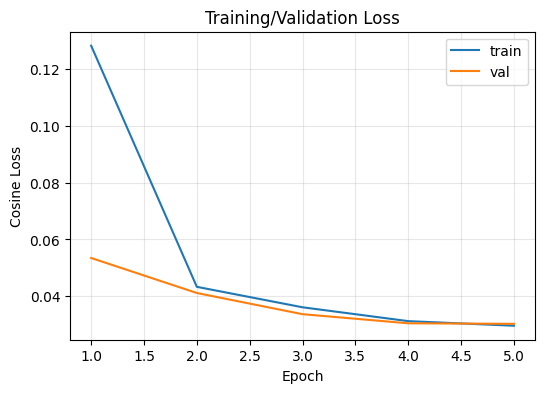

In [20]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_hist) + 1) if 'train_hist' in globals() else []
plt.figure(figsize=(6,4))
if epochs:
    plt.plot(epochs, train_hist, label='train')
    plt.plot(epochs, val_hist, label='val')
    plt.xlabel('Epoch')
    plt.ylabel('Cosine Loss')
    plt.title('Training/Validation Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
else:
    print('Run the training cell first to populate train_hist/val_hist.')
plt.show()


# Testing Model with Zero State

In [21]:
def interleave_tensor_pqc_in_circuit(base_ops:list, qubits:int, blocks:int, pqc_gates:list, params:list):
    """Interleave PQC operations into the base circuit."""
    interleaved_circuit = []
    # print(params.shape)
    for i, op in enumerate(base_ops):
        # print(i, op)
        interleaved_circuit.append(op)
        if (i + 1) % blocks == 0:
            k = (i + 1) // blocks - 1
            # print(f"Interleaving PQC operations for block {k}")
            for q in range(qubits):
                for j, g in enumerate(pqc_gates):
                    # print(g, q, (k,q,j), params[k, q, j])
                    interleaved_circuit.append((g, [q], params[k, q, j].detach().numpy()))
    return interleaved_circuit

In [25]:
from pqcqec.noise.simple_noise import PennylaneNoisyGates
from pqcqec.simulate.simulate import run_circuit_with_noise_model
from pqcqec.training.jax_loss_functions import jax_pure_state_fidelity

import jax.numpy as jnp

noise_model = PennylaneNoisyGates(**NOISE_DIST)
no_noise_model = PennylaneNoisyGates(0,0,0,0)
# NUM_QUBITS = 5
ZERO_STATE = jnp.zeros((2 ** NUM_QUBITS,), dtype=jnp.complex64).at[0].set(1.0)


In [26]:
simple_model.eval()  # Set the model to evaluation mode
test_fid_model = []
test_fid_default = []
for i, data in enumerate(qc_test_dataloader):

    data = data

    input_ids = data['input_ids'].to(device)
    attention_mask = data['attention_mask'].to(device)
    # pqc_params = params[0]

    circuit_ops = qc_tokenizer.decode(input_ids[0].cpu().numpy().tolist())
    # circuit_ops = [(op[0], op[1], []) for op in circuit_ops]  # Add params placeholder from the circuit ops
    # pqc_circuit = interleave_tensor_pqc_in_circuit(circuit_ops, NUM_QUBITS, GATE_BLOCKS, PQC_GATES, pqc_params)


    pred_theta = simple_model(input_ids, attention_mask=attention_mask)[0].to('cpu')

    circuit_interleaved = interleave_tensor_pqc_in_circuit(circuit_ops, NUM_QUBITS, GATE_BLOCKS, PQC_GATES, pred_theta)

    ideal_out_state = run_circuit_with_noise_model(circuit_ops, ZERO_STATE, no_noise_model, NUM_QUBITS)

    measured_modelPQC = run_circuit_with_noise_model(circuit_interleaved, ZERO_STATE, noise_model, NUM_QUBITS)
    # measured_defaultPQC = run_circuit_with_noise_model(pqc_circuit, ZERO_STATE, noise_model, NUM_QUBITS)

    # print(ZERO_STATE)
    # print(measured_modelPQC)

    fidelity_modelPQC = jax_pure_state_fidelity(ideal_out_state, measured_modelPQC)
    # fidelity_defaultPQC = jax_pure_state_fidelity(ideal_out_state, measured_defaultPQC)

    test_fid_model.append(fidelity_modelPQC)
    # test_fid_default.append(fidelity_defaultPQC)

    # print(f"Fidelity (Model PQC): {fidelity_modelPQC:.4e}, Fidelity (Default PQC): {fidelity_defaultPQC:.4e}")

In [27]:
print(f"Net Fidelity (Model PQC): {np.mean(test_fid_model):.4e}, Net Fidelity (Default PQC): {np.mean(test_fid_default):.4e}")

Net Fidelity (Model PQC): 1.3132e-01, Net Fidelity (Default PQC): nan


/home/ashutosh/Research-Code/pqc-qec/.venv/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/ashutosh/Research-Code/pqc-qec/.venv/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
